
=== Baseline design ===
Baseline MDE @ α=0.05, 80.0% power: 3.183%


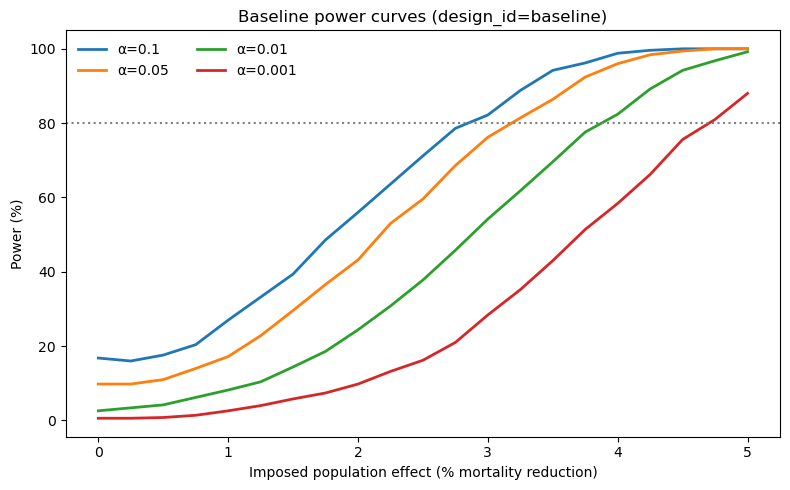


=== LLM proposing adjacent design variants (same dataset) ===
Wrote adjacent_design_variants.json

=== Running variant variant_1 ===
Rationale: Increase post_years to capture longer-term effects, potentially improving power by including more post-treatment data.


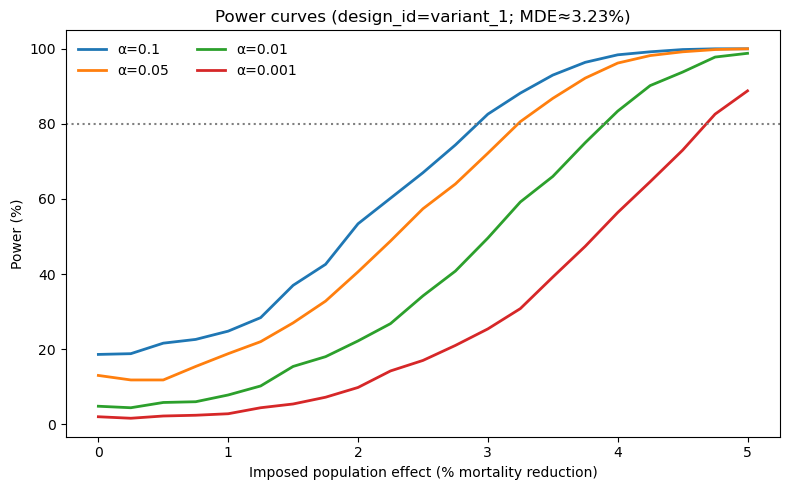


=== Running variant variant_2 ===
Rationale: Reduce pre_years to 3 to focus on a shorter pre-treatment period, which may reduce noise from older data and affect detectability.


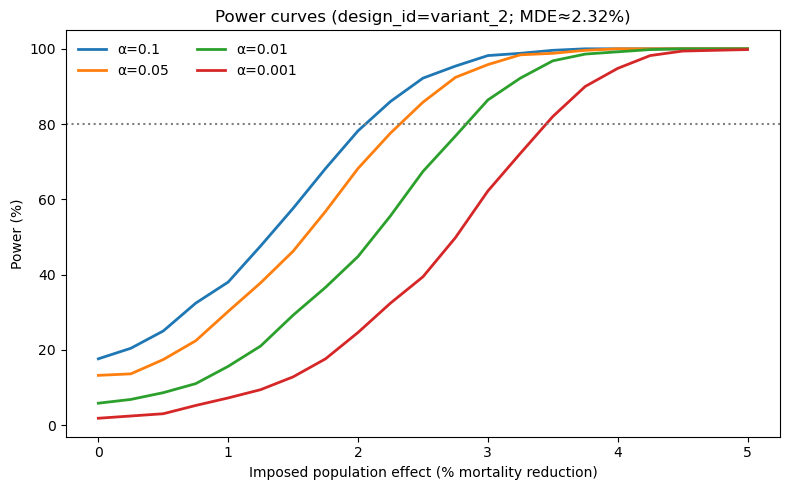


=== Running variant variant_3 ===
Rationale: Increase n_treated to 35 to improve power by increasing sample size of treated units.


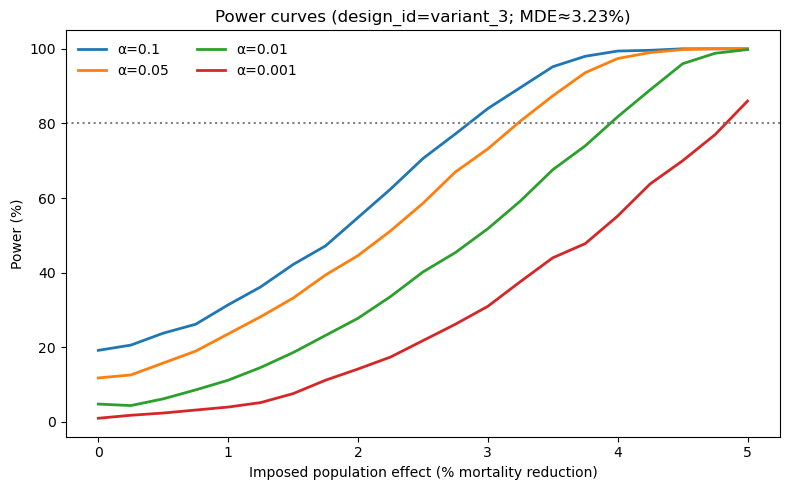


=== Running variant variant_4 ===
Rationale: Increase effect_grid_end to 0.08 and effect_grid_step to 0.005 to explore a wider and coarser effect size grid, potentially reducing computation while testing larger effects.


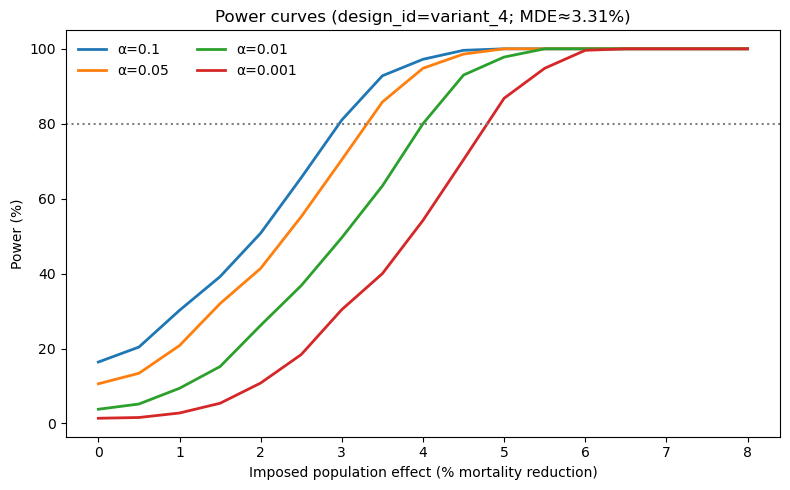


Wrote adjacent_design_power_results.csv

MDE summary (lower is more powered):
   design_id   mde_pct  last_year  pre_years  post_years  n_treated  n_sim
1  variant_2  2.323171       2011          3           3         23    500
0  variant_1  3.225806       2012          5           4         23    500
2  variant_3  3.229730       2011          5           3         35    500
3  variant_4  3.311688       2011          5           3         23    500


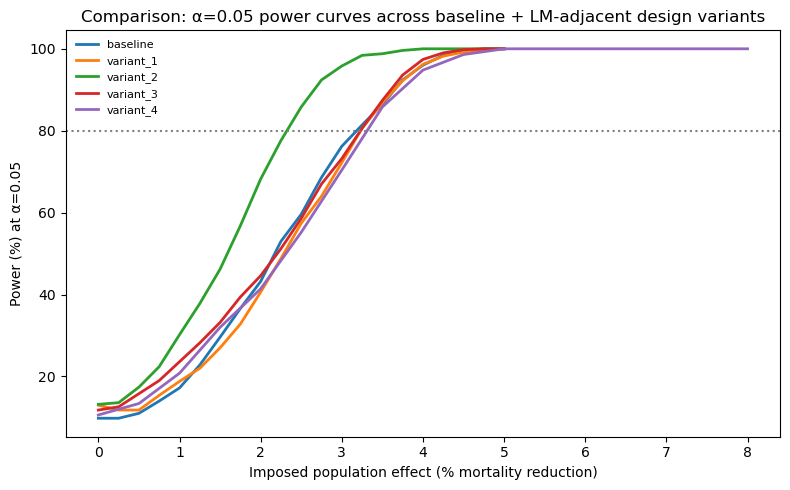

In [1]:
"""
Adjacent power analyses WITHOUT new datasets.

Pipeline:
A) Baseline simulated power curve for a TWFE DiD toy design (state×year).
B) LLM proposes adjacent design variants (pre/post window, pseudo adoption year, n_treated, effect grid).
C) For each design variant, run the SAME simulation on the SAME dataset and compute MDE.
D) Output:
   - MDE table by design
   - Figures: for each design, power curves for multiple alpha levels in one figure
"""

from __future__ import annotations

import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t

from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel, Field


# =============================================================================
# SETTINGS
# =============================================================================

BASELINE_PATH = Path("Multiple Cause of Death, 1999-2020.csv")

ALPHAS = [0.10, 0.05, 0.01, 0.001]
TARGET_POWER = 80.0
ALPHA_FOR_MDE = 0.05

N_SIM_DEFAULT = 500
RNG_SEED = 1234

# baseline design (same as your current)
BASELINE_DESIGN = dict(
    design_id="baseline",
    first_year=2006,
    last_year=2011,          # pseudo post starts here (>=last_year)
    pre_years=5,
    post_years=3,
    n_treated=23,
    n_sim=N_SIM_DEFAULT,
    effect_grid_step=0.0025,
    effect_grid_end=0.05,
)

# =============================================================================
# A) LOAD ONE WONDER DATASET
# =============================================================================

def load_wonder_state_year(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df = df[df["year"].notna()].copy()
    df["year"] = df["year"].astype(int)

    df["deaths"] = pd.to_numeric(df["deaths"], errors="coerce")
    df["population"] = pd.to_numeric(df["population"], errors="coerce")
    df = df.dropna(subset=["deaths", "population"])

    if "state_code" in df.columns:
        df["state_id"] = pd.to_numeric(df["state_code"], errors="coerce").astype(int)
    elif "statecode" in df.columns:
        df["state_id"] = pd.to_numeric(df["statecode"], errors="coerce").astype(int)
    else:
        raise ValueError("Missing state_code/statecode column")

    df = df.sort_values(["state_id", "year"]).reset_index(drop=True)
    return df


# =============================================================================
# B) POWER SIM CORE (parameterized by design variant)
# =============================================================================

def simulate_power_for_design(df_all: pd.DataFrame, design: dict, seed: int) -> pd.DataFrame:
    """
    Same simulation as before, but parameterized by design:
      - year window based on (first_year, pre_years, post_years, last_year)
      - n_treated
      - effect grid step/end
      - n_sim
    """
    rng = np.random.default_rng(seed)

    # design window
    first_year = int(design["first_year"])
    last_year = int(design["last_year"])     # pseudo post begins here
    pre_years = int(design["pre_years"])
    post_years = int(design["post_years"])

    # implied window:
    # pre: [last_year - pre_years, last_year-1]
    # post: [last_year, last_year+post_years-1]
    win_start = last_year - pre_years
    win_end = last_year + post_years         # exclusive

    df = df_all[(df_all["year"] >= win_start) & (df_all["year"] < win_end)].copy()
    if df.empty:
        raise ValueError(f"Empty window for design {design['design_id']}: {win_start}-{win_end-1}")

    # effect grid
    step = float(design["effect_grid_step"])
    endv = float(design["effect_grid_end"])
    effect_grid = np.arange(0, endv + 1e-12, step)

    n_sim = int(design["n_sim"])
    n_treated = int(design["n_treated"])

    # index encoding
    state_codes = np.sort(df["state_id"].unique())
    year_vals = np.sort(df["year"].unique())
    state_to_idx = {s:i for i,s in enumerate(state_codes)}
    year_to_idx  = {y:i for i,y in enumerate(year_vals)}

    s = df["state_id"].map(state_to_idx).to_numpy()
    tt = df["year"].map(year_to_idx).to_numpy()
    S, T = len(state_codes), len(year_vals)

    deaths0 = df["deaths"].to_numpy().astype(int)
    pop = df["population"].to_numpy().astype(float)
    w = pop
    post = (df["year"].to_numpy() >= last_year).astype(int)

    def twoway_demean(x: np.ndarray) -> np.ndarray:
        x_bar = (w * x).sum() / w.sum()
        xs = np.bincount(s, weights=w * x, minlength=S) / np.bincount(s, weights=w, minlength=S)
        xt = np.bincount(tt, weights=w * x, minlength=T) / np.bincount(tt, weights=w, minlength=T)
        return x - xs[s] - xt[tt] + x_bar

    def twfe_beta_se(y: np.ndarray, d: np.ndarray):
        yt = twoway_demean(y)
        dt = twoway_demean(d)

        bread = np.sum(w * dt * dt)
        beta = np.sum(w * dt * yt) / bread

        u = yt - beta * dt
        score_g = np.bincount(s, weights=(w * dt * u), minlength=S)
        var_beta = np.sum(score_g**2) / (bread**2)

        return beta, np.sqrt(var_beta), (S - 1)

    J = len(effect_grid)
    pvals = np.empty((n_sim, J))
    state_idx = np.arange(S)

    for k in range(n_sim):
        treated_states = rng.choice(state_idx, size=min(n_treated, S), replace=False)
        treated = np.isin(s, treated_states).astype(int)
        d = treated * post

        for j, eff in enumerate(effect_grid):
            removed = rng.binomial(n=deaths0, p=eff) * d
            deaths_eff = deaths0 - removed

            y = np.log((deaths_eff / pop) * 100000.0 + 1.0)
            beta, se_beta, df_t = twfe_beta_se(y, d)

            b_pct = 100.0 * (np.exp(beta) - 1.0)
            se_pct = 100.0 * np.exp(beta) * se_beta
            tstat = b_pct / se_pct
            pvals[k, j] = 2 * t.sf(np.abs(tstat), df=df_t)

    out = pd.DataFrame({"effect_size_pct": effect_grid * 100})
    for a in ALPHAS:
        out[f"power_{a:.3f}"] = (pvals <= a).mean(axis=0) * 100

    return out


def mde_from_power_curve(power_df: pd.DataFrame, alpha=ALPHA_FOR_MDE, target_power=TARGET_POWER) -> float:
    col = f"power_{alpha:.3f}"
    gap = np.abs(power_df[col] - target_power)
    i1, i2 = np.argsort(gap.values)[:2]
    x1, x2 = power_df.loc[[i1, i2], "effect_size_pct"].values
    y1, y2 = power_df.loc[[i1, i2], col].values
    m = (y2 - y1) / (x2 - x1)
    b0 = y1 - m * x1
    return float((target_power - b0) / m)


# =============================================================================
# C) LLM: PROPOSE ADJACENT DESIGN VARIANTS (no new datasets)
# =============================================================================

class DesignVariant(BaseModel):
    design_id: str
    rationale: str
    # must be runnable on same dataset:
    last_year: int = Field(..., description="Pseudo post begins at this year")
    pre_years: int = Field(..., ge=3, le=12)
    post_years: int = Field(..., ge=1, le=10)
    n_treated: int = Field(..., ge=5, le=45)
    effect_grid_step: float = Field(..., ge=0.001, le=0.01)
    effect_grid_end: float = Field(..., ge=0.02, le=0.10)
    n_sim: int = Field(..., ge=50, le=800)

class DesignMenu(BaseModel):
    variants: list[DesignVariant]

def propose_design_variants_via_llm(baseline: dict, k: int = 4) -> DesignMenu:
    load_dotenv()
    client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

    prompt = f"""
You are helping propose adjacent POWER ANALYSIS designs (not new outcomes) using the SAME state×year mortality dataset.

Baseline design parameters:
{json.dumps(baseline, indent=2)}

Task:
Propose {k} alternative design variants that could plausibly change detectability (power/MDE) WITHOUT requiring new data.
You may vary only:
- last_year (pseudo post start year)
- pre_years
- post_years
- n_treated
- effect_grid_step and effect_grid_end
- n_sim

Constraints:
- Use last_year in [2008, 2012]
- pre_years in [3, 12]
- post_years in [1, 10]
- n_treated in [5, 45]
- effect_grid_step in [0.001, 0.01]
- effect_grid_end in [0.02, 0.10]
- n_sim in [50, 800]

Return ONLY valid JSON:
{{
  "variants": [
    {{
      "design_id": "...",
      "rationale": "...",
      "last_year": 2011,
      "pre_years": 5,
      "post_years": 3,
      "n_treated": 23,
      "effect_grid_step": 0.0025,
      "effect_grid_end": 0.05,
      "n_sim": 200
    }}
  ]
}}
No markdown.
"""
    resp = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[
            {"role":"system","content":"Return only valid JSON. No markdown."},
            {"role":"user","content":prompt},
        ],
        temperature=0.3,
    )
    raw = resp.choices[0].message.content
    return DesignMenu.model_validate_json(raw)


# =============================================================================
# D) PLOTTING HELPERS (multiple alpha curves in one figure)
# =============================================================================

def plot_power_curves_multi_alpha(power_df: pd.DataFrame, title: str):
    plt.figure(figsize=(8,5))
    for a in ALPHAS:
        plt.plot(power_df["effect_size_pct"], power_df[f"power_{a:.3f}"], lw=2, label=f"α={a:g}")
    plt.axhline(80, color="gray", ls=":", lw=1.5)
    plt.xlabel("Imposed population effect (% mortality reduction)")
    plt.ylabel("Power (%)")
    plt.title(title)
    plt.legend(frameon=False, ncols=2)
    plt.tight_layout()
    plt.show()


# =============================================================================
# MAIN
# =============================================================================

def main():
    df_all = load_wonder_state_year(BASELINE_PATH)

    # baseline power
    print("\n=== Baseline design ===")
    power0 = simulate_power_for_design(df_all, BASELINE_DESIGN, seed=RNG_SEED)
    mde0 = mde_from_power_curve(power0)
    print(f"Baseline MDE @ α={ALPHA_FOR_MDE}, {TARGET_POWER}% power: {mde0:.3f}%")

    plot_power_curves_multi_alpha(power0, f"Baseline power curves (design_id={BASELINE_DESIGN['design_id']})")

    # ask LM for design variants
    print("\n=== LLM proposing adjacent design variants (same dataset) ===")
    menu = propose_design_variants_via_llm(BASELINE_DESIGN, k=4)
    with open("adjacent_design_variants.json", "w", encoding="utf-8") as f:
        f.write(menu.model_dump_json(indent=2))
    print("Wrote adjacent_design_variants.json")

    # run each variant
    results = []
    power_by_design = {"baseline": power0}

    for v in menu.variants:
        design = BASELINE_DESIGN.copy()
        design.update({
            "design_id": v.design_id,
            "last_year": v.last_year,
            "pre_years": v.pre_years,
            "post_years": v.post_years,
            "n_treated": v.n_treated,
            "effect_grid_step": v.effect_grid_step,
            "effect_grid_end": v.effect_grid_end,
            "n_sim": v.n_sim
        })

        print(f"\n=== Running variant {v.design_id} ===")
        print("Rationale:", v.rationale)

        power_v = simulate_power_for_design(df_all, design, seed=RNG_SEED + hash(v.design_id) % 10000)
        mde_v = mde_from_power_curve(power_v)

        results.append({
            "design_id": v.design_id,
            "rationale": v.rationale,
            "last_year": v.last_year,
            "pre_years": v.pre_years,
            "post_years": v.post_years,
            "n_treated": v.n_treated,
            "effect_grid_step": v.effect_grid_step,
            "effect_grid_end": v.effect_grid_end,
            "n_sim": v.n_sim,
            "mde_pct": mde_v
        })
        power_by_design[v.design_id] = power_v

        plot_power_curves_multi_alpha(power_v, f"Power curves (design_id={v.design_id}; MDE≈{mde_v:.2f}%)")

    # results table
    res_df = pd.DataFrame(results).sort_values("mde_pct")
    res_df.to_csv("adjacent_design_power_results.csv", index=False)
    print("\nWrote adjacent_design_power_results.csv")
    print("\nMDE summary (lower is more powered):")
    print(res_df[["design_id","mde_pct","last_year","pre_years","post_years","n_treated","n_sim"]])

    # optional: one comparison plot at alpha=0.05 for all variants
    plt.figure(figsize=(8,5))
    for k, dfp in power_by_design.items():
        plt.plot(dfp["effect_size_pct"], dfp[f"power_{0.05:.3f}"], lw=2, label=k)
    plt.axhline(80, color="gray", ls=":")
    plt.xlabel("Imposed population effect (% mortality reduction)")
    plt.ylabel("Power (%) at α=0.05")
    plt.title("Comparison: α=0.05 power curves across baseline + LM-adjacent design variants")
    plt.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()